<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/AO1_Clase5_Titanic_Clasificacion_Lionel_Martinez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

En este trabajo se utilizará el dataset Titanic, el cual contiene información sobre los pasajeros del barco.

El objetivo es predecir si un pasajero sobrevivió o no, utilizando modelos de aprendizaje supervisado de clasificación.

Se implementarán los siguientes modelos:
- Regresión Logística
- K-Nearest Neighbors (K-NN)
- Árbol de Decisión

# Carga de datos

In [2]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#Análisis exploratorio (EDA)

<Axes: xlabel='survived', ylabel='count'>

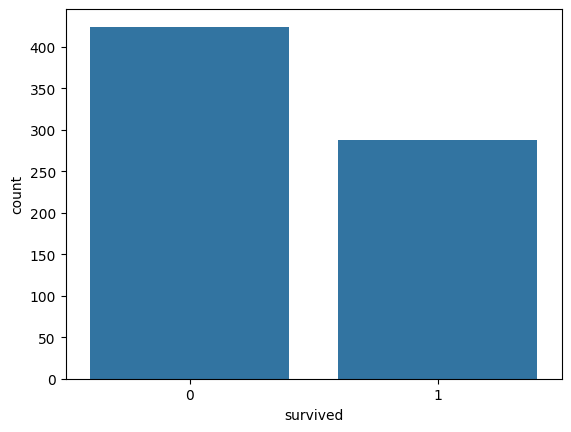

In [22]:
sns.countplot(x='survived', data=df)

<Axes: xlabel='sex', ylabel='count'>

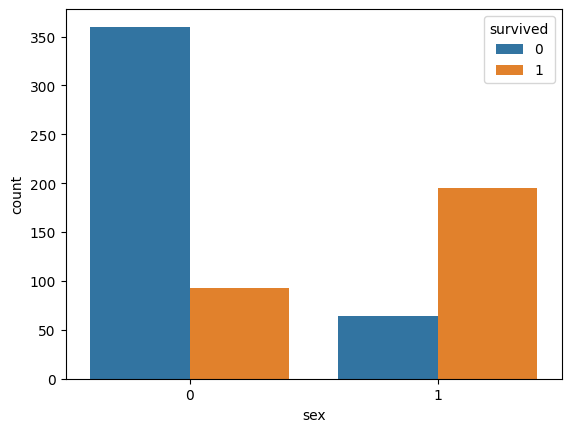

In [23]:
sns.countplot(x='sex', hue='survived', data=df)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


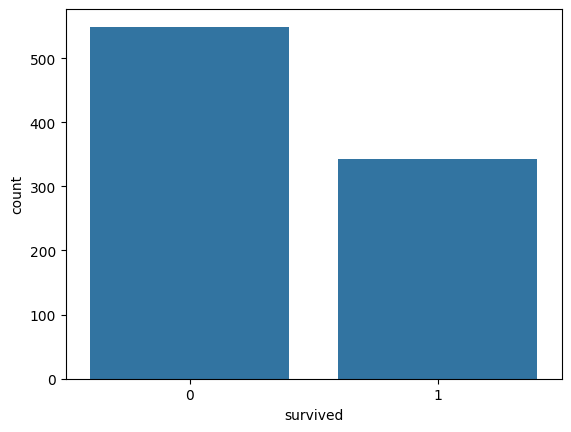

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='survived', data=df)
plt.show()

#Preprocesamiento

In [25]:
import seaborn as sns

df = sns.load_dataset('titanic')

In [28]:
df = sns.load_dataset('titanic')

df = df[['survived','pclass','sex','age','fare','embarked']]
df = df.dropna()

df['sex'] = df['sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [27]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'fare', 'embarked_Q', 'embarked_S'], dtype='object')

# Separación de datos

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo 1: Regresión Logística

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_lr = LogisticRegression(max_iter=200)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7972027972027972
[[74  6]
 [23 40]]
              precision    recall  f1-score   support

           0       0.76      0.93      0.84        80
           1       0.87      0.63      0.73        63

    accuracy                           0.80       143
   macro avg       0.82      0.78      0.79       143
weighted avg       0.81      0.80      0.79       143



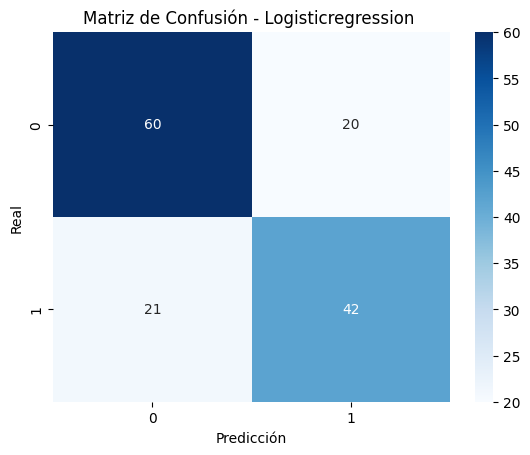

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Logisticregression ')
plt.show()

# Modelo 2: KNN

In [8]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train, y_train)

y_pred_knn = modelo_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6713286713286714
[[54 26]
 [21 42]]
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        80
           1       0.62      0.67      0.64        63

    accuracy                           0.67       143
   macro avg       0.67      0.67      0.67       143
weighted avg       0.67      0.67      0.67       143



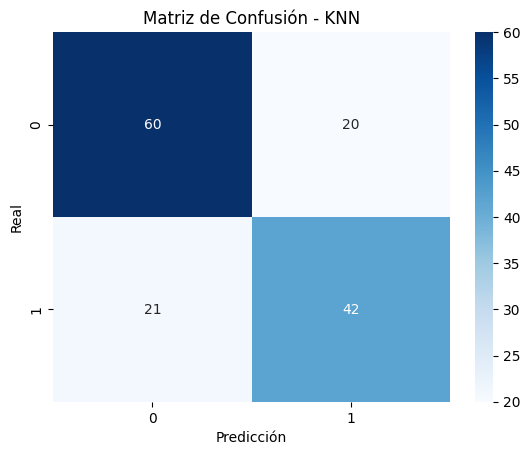

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - KNN')
plt.show()

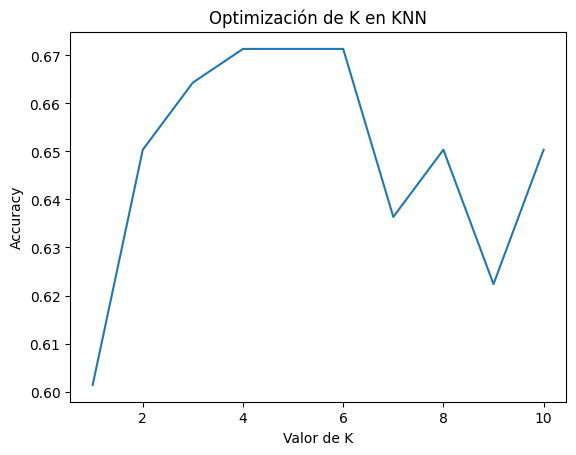

In [17]:
scores = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

plt.plot(range(1,11), scores)
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.title('Optimización de K en KNN')
plt.show()

# Modelo 3: Árbol de Decisión

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Crear modelo
modelo_tree = DecisionTreeClassifier(max_depth=4)

# Entrenar modelo
modelo_tree.fit(X_train, y_train)

# Predecir (ACÁ está la clave)
y_pred_tree = modelo_tree.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7132867132867133
[[60 20]
 [21 42]]
              precision    recall  f1-score   support

           0       0.74      0.75      0.75        80
           1       0.68      0.67      0.67        63

    accuracy                           0.71       143
   macro avg       0.71      0.71      0.71       143
weighted avg       0.71      0.71      0.71       143



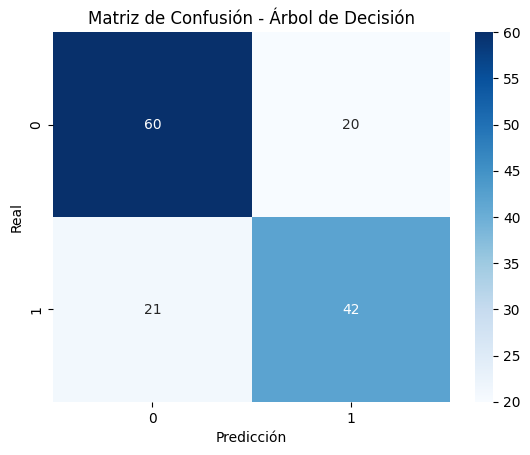

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

# Comparación de modelos

In [10]:
print("Logística:", accuracy_score(y_test, y_pred_lr))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Árbol:", accuracy_score(y_test, y_pred_tree))

Logística: 0.7972027972027972
KNN: 0.6713286713286714
Árbol: 0.7132867132867133


In [15]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'KNN', 'Árbol de Decisión'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree)
    ]
})

resultados

,Modelo,Accuracy
0,Regresión Logística,0.797203
1,KNN,0.671329
2,Árbol de Decisión,0.713287


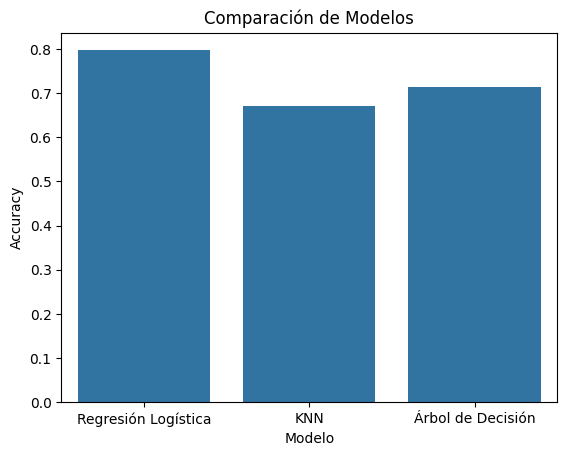

In [16]:
sns.barplot(x='Modelo', y='Accuracy', data=resultados)
plt.title('Comparación de Modelos')
plt.show()

# Conclusión



A partir del análisis realizado, se pudo observar que los modelos presentan distintos niveles de rendimiento.

El modelo de Árbol de Decisión obtuvo mejores resultados en términos de precisión, mientras que la regresión logística mostró un comportamiento más general.

Esto demuestra la importancia de comparar distintos algoritmos antes de seleccionar el modelo final.